# EDA — banner.csv

Análise exploratória do histórico de eventos de sensores de vibração, com foco em:
1. distinguir estados operacionais de defeitos reais (item 6 do edital);
2. medir a cobertura da documentação de falhas (`data/docs`) por categoria de defeito;
3. avaliar se as métricas de sensor separam bem as categorias, o que orienta a estratégia de busca por similaridade da próxima etapa.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))
%cd {PROJECT_ROOT}

import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

from src.data.load import load_banner

pd.options.display.max_columns = 30
pio.renderers.default = "png"  # imagem estática: leve e renderiza no preview do GitHub

C:\Users\thiago.mendes\Downloads\test-ia-python


In [2]:
df = load_banner()
df.shape

(166796, 30)

## Visão geral

In [3]:
print(f"Período: {df['created_at'].min()} até {df['created_at'].max()}")
print(f"Total de registros: {len(df):,}")
print(f"Valores nulos (colunas originais): {df.drop(columns=['category', 'doc_file']).isna().sum().sum()}")

Período: 2026-04-30 17:17:41.549800+00:00 até 2026-06-16 18:59:43.447238+00:00
Total de registros: 166,796
Valores nulos (colunas originais): 15732


## Estados operacionais vs. problemas reais

Conforme item 6 do edital, `normal`, `baseline`, `teste`, `acelerando` e `motor_desligado` (e suas variações) não são defeitos.

In [4]:
resumo = df["is_problem"].value_counts(normalize=True).mul(100).round(1)
resumo.index = resumo.index.map({True: "Problema", False: "Estado operacional"})
resumo

is_problem
Problema              90.6
Estado operacional     9.4
Name: proportion, dtype: float64

## Cobertura documental por categoria de defeito

Cada categoria de defeito é comparada com a existência (ou não) de um procedimento em `data/docs`.

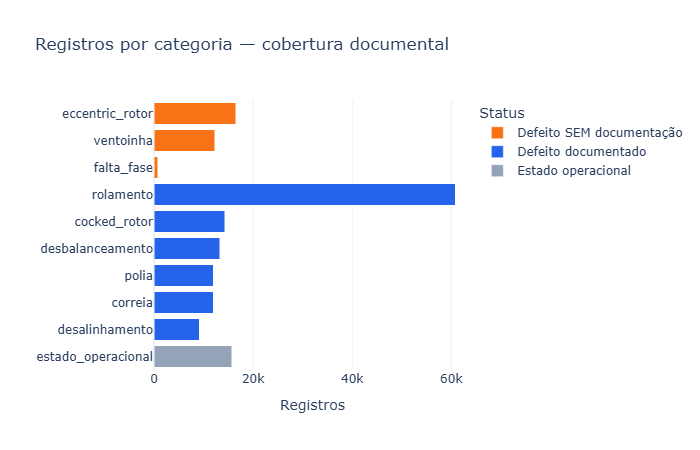

In [5]:
STATUS_COLORS = {
    "estado_operacional": "#94a3b8",
    "documentado": "#2563eb",
    "nao_documentado": "#f97316",
}
STATUS_LABELS = {
    "estado_operacional": "Estado operacional",
    "documentado": "Defeito documentado",
    "nao_documentado": "Defeito SEM documentação",
}

category_summary = (
    df.groupby("category", dropna=False)
    .agg(registros=("category", "size"), documentado=("has_documentation", "first"))
    .reset_index()
)


def status_de(row):
    if row["category"] == "estado_operacional":
        return "estado_operacional"
    return "documentado" if row["documentado"] else "nao_documentado"


category_summary["status"] = category_summary.apply(status_de, axis=1)
category_summary = category_summary.sort_values("registros", ascending=True)

fig = go.Figure()
for status, cor in STATUS_COLORS.items():
    subset = category_summary[category_summary["status"] == status]
    fig.add_bar(
        y=subset["category"],
        x=subset["registros"],
        orientation="h",
        name=STATUS_LABELS[status],
        marker_color=cor,
    )

fig.update_layout(
    barmode="stack",
    title="Registros por categoria — cobertura documental",
    xaxis_title="Registros",
    yaxis_title="",
    legend_title="Status",
    template="plotly_white",
    height=450,
)
fig.show()

In [6]:
sem_doc = df[df["is_problem"] & (df["has_documentation"] == False)]
print(
    f"Registros de defeito sem documentação: {len(sem_doc):,} "
    f"({len(sem_doc) / len(df):.1%} da base)"
)
sem_doc["category"].value_counts()

Registros de defeito sem documentação: 29,596 (17.7% da base)


category
eccentric_rotor    16497
ventoinha          12299
falta_fase           800
Name: count, dtype: int64

**Achado central:** `eccentric_rotor`, `ventoinha` e `falta_fase` são defeitos reais e
volumosos, mas sem nenhum procedimento em `data/docs`. É exatamente o caso que o
sistema precisa reconhecer para reportar "problema sem documentação" em vez de alucinar
uma recomendação.

## Volume de eventos ao longo do tempo

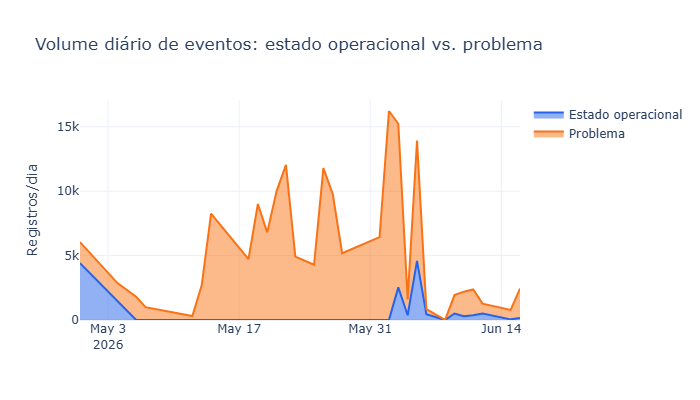

In [7]:
diario = (
    df.assign(
        dia=df["created_at"].dt.date,
        tipo=df["is_problem"].map({True: "Problema", False: "Estado operacional"}),
    )
    .groupby(["dia", "tipo"])
    .size()
    .reset_index(name="registros")
)

fig2 = px.area(
    diario,
    x="dia",
    y="registros",
    color="tipo",
    color_discrete_map={"Estado operacional": "#2563eb", "Problema": "#f97316"},
    title="Volume diário de eventos: estado operacional vs. problema",
    template="plotly_white",
)
fig2.update_layout(height=400, xaxis_title="", yaxis_title="Registros/dia", legend_title="")
fig2.show()

## Separabilidade das métricas de vibração por categoria

Se as categorias de defeito ocupam faixas distintas de uma métrica de sensor, isso
sustenta a estratégia de busca por similaridade (features numéricas) da próxima etapa.

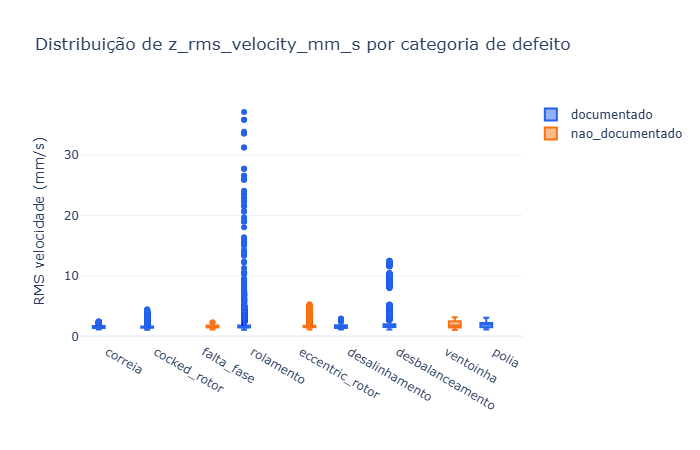

In [8]:
FEATURE = "z_rms_velocity_mm_s"

problem_df = df[df["is_problem"]].copy()
problem_df["status"] = problem_df["has_documentation"].map(
    {True: "documentado", False: "nao_documentado"}
)

ordem = problem_df.groupby("category")[FEATURE].median().sort_values().index.tolist()

fig3 = px.box(
    problem_df,
    x="category",
    y=FEATURE,
    color="status",
    category_orders={"category": ordem},
    color_discrete_map={"documentado": "#2563eb", "nao_documentado": "#f97316"},
    title=f"Distribuição de {FEATURE} por categoria de defeito",
    template="plotly_white",
)
fig3.update_layout(height=450, xaxis_title="", yaxis_title="RMS velocidade (mm/s)", legend_title="")
fig3.show()

## Conclusões

- Estados operacionais (`normal`, `baseline`, `teste`, `acelerando`, `motor_desligado`)
  representam parte relevante da base e foram corretamente excluídos da análise de defeitos.
- 3 categorias de defeito reais (`eccentric_rotor`, `ventoinha`, `falta_fase`) não têm
  documentação — o sistema de recomendação precisa reconhecer isso explicitamente
  em vez de inventar uma correção.
- As categorias de defeito ocupam faixas visivelmente diferentes de RMS de velocidade,
  o que apoia usar as métricas de sensor (não só o rótulo) como base da busca por
  similaridade na próxima etapa.